---

VIX calibration

---

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
from rbergomi import RoughBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
COLORS = ["blue", "green", "red", "orange"]
SEED = 1234

# 22 Nov 2017

In [68]:
# load market data
df = pd.read_csv("data/vix_smile_2017.csv", sep=";")
df = df.iloc[0:9]
tab_strike = 1e-2 * df.iloc[0][4:-2].to_numpy().astype(float)
tab_mat = np.arange(1, 9) / 12
tab_fut = 1e-2 * df["F"][1:].to_numpy().astype(float)
tab_impvol = np.zeros((8, 16))
for i in range(1, 9):
    tab_impvol[i - 1, :] = np.array(df.iloc[i][4:-2]) / 100

In [69]:
tab_fut

array([0.1148, 0.1288, 0.1383, 0.1458, 0.1518, 0.1568, 0.1613, 0.167 ])

In [70]:
H = 0.1

list_x0 = np.array(
    [
        np.log(0.014483720994143206),
        np.log(0.0213),
        np.log(0.02629),
        np.log(0.02927),
    ]
)
list_eta1 = np.array([1.89695265, 1.85768486, 1.746, 1.40721303]) / np.sqrt(2 * H)
list_eta2 = np.array([0.19704152, 0.15271809, 0.167, 0.12376835]) / np.sqrt(2 * H)
list_lbd = np.array([0.32418895, 0.49170964, 0.55, 0.6499])

In [130]:
EPS = 1e-3
N_QUAD = 40
ORDER = 0

impvol_approx = {}
fut_approx = {}


for i in range(len(list_x0)):
    params = {
        "s0": 1.0,
        "xi0": lambda u: np.ones_like(u) * np.exp(list_x0[i]),
        "rho": -0.7,
        "H": H,
        "eta": list_eta1[i],
    }
    rbergomi = RoughBergomi(**params)

    lbd = list_lbd[i]
    eta_2 = list_eta2[i]
    T = tab_mat[i]
    fut_approx[T] = rbergomi.price_vix_approx_mixed(
        T=T,
        K=0.0,
        lbd=lbd,
        eta_2=eta_2,
        order=ORDER,
        opt_payoff="fut",
        eps=EPS,
        n_quad=N_QUAD,
    )
    k = np.log(tab_strike / fut_approx[T])

    impvol_approx[T] = rbergomi.implied_vol_vix_approx_mixed(
        lbd=lbd,
        eta_2=eta_2,
        k=k,
        T=T,
        order=ORDER,
        eps=EPS,
        n_quad=N_QUAD,
    )

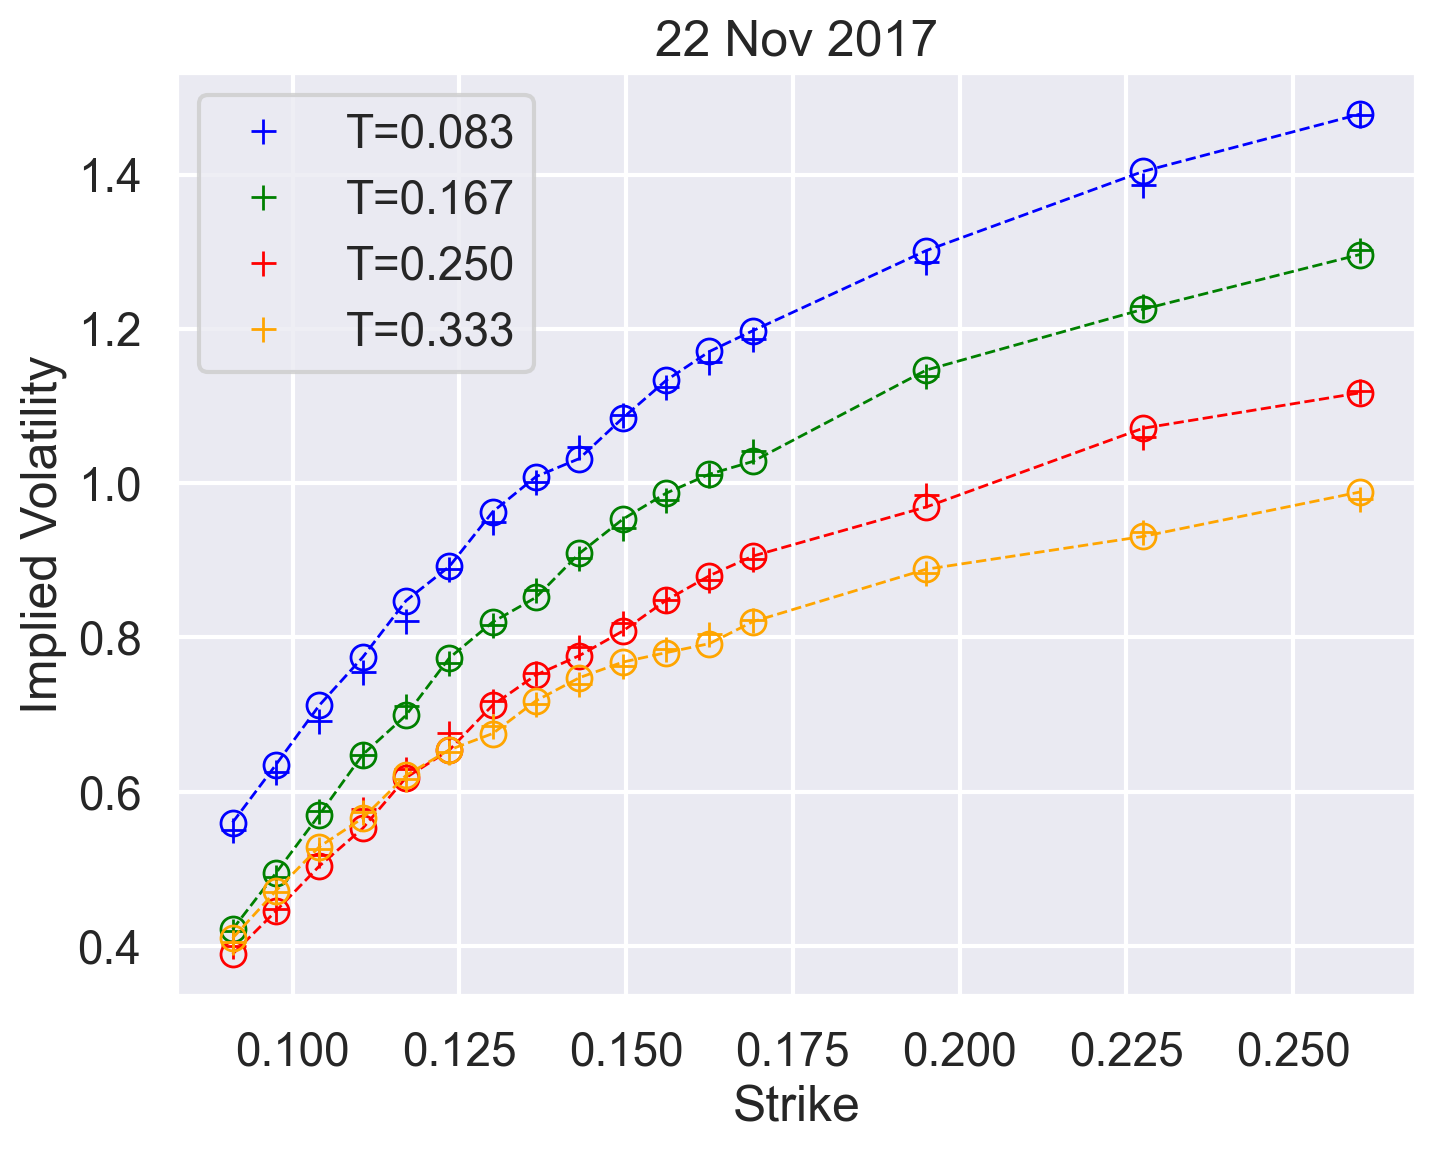

In [131]:
# plot vix smiles
fig, ax = plt.subplots()
for i in range(4):
    ax.plot(
        tab_strike,
        tab_impvol[i, :],
        "+",
        color=COLORS[i],
        label=f"T={tab_mat[i]:.3f}",
    )
    ax.plot(
        tab_strike,
        impvol_approx[tab_mat[i]],
        "--o",
        color=COLORS[i],
        fillstyle="none",
        linewidth=1.0,
    )
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

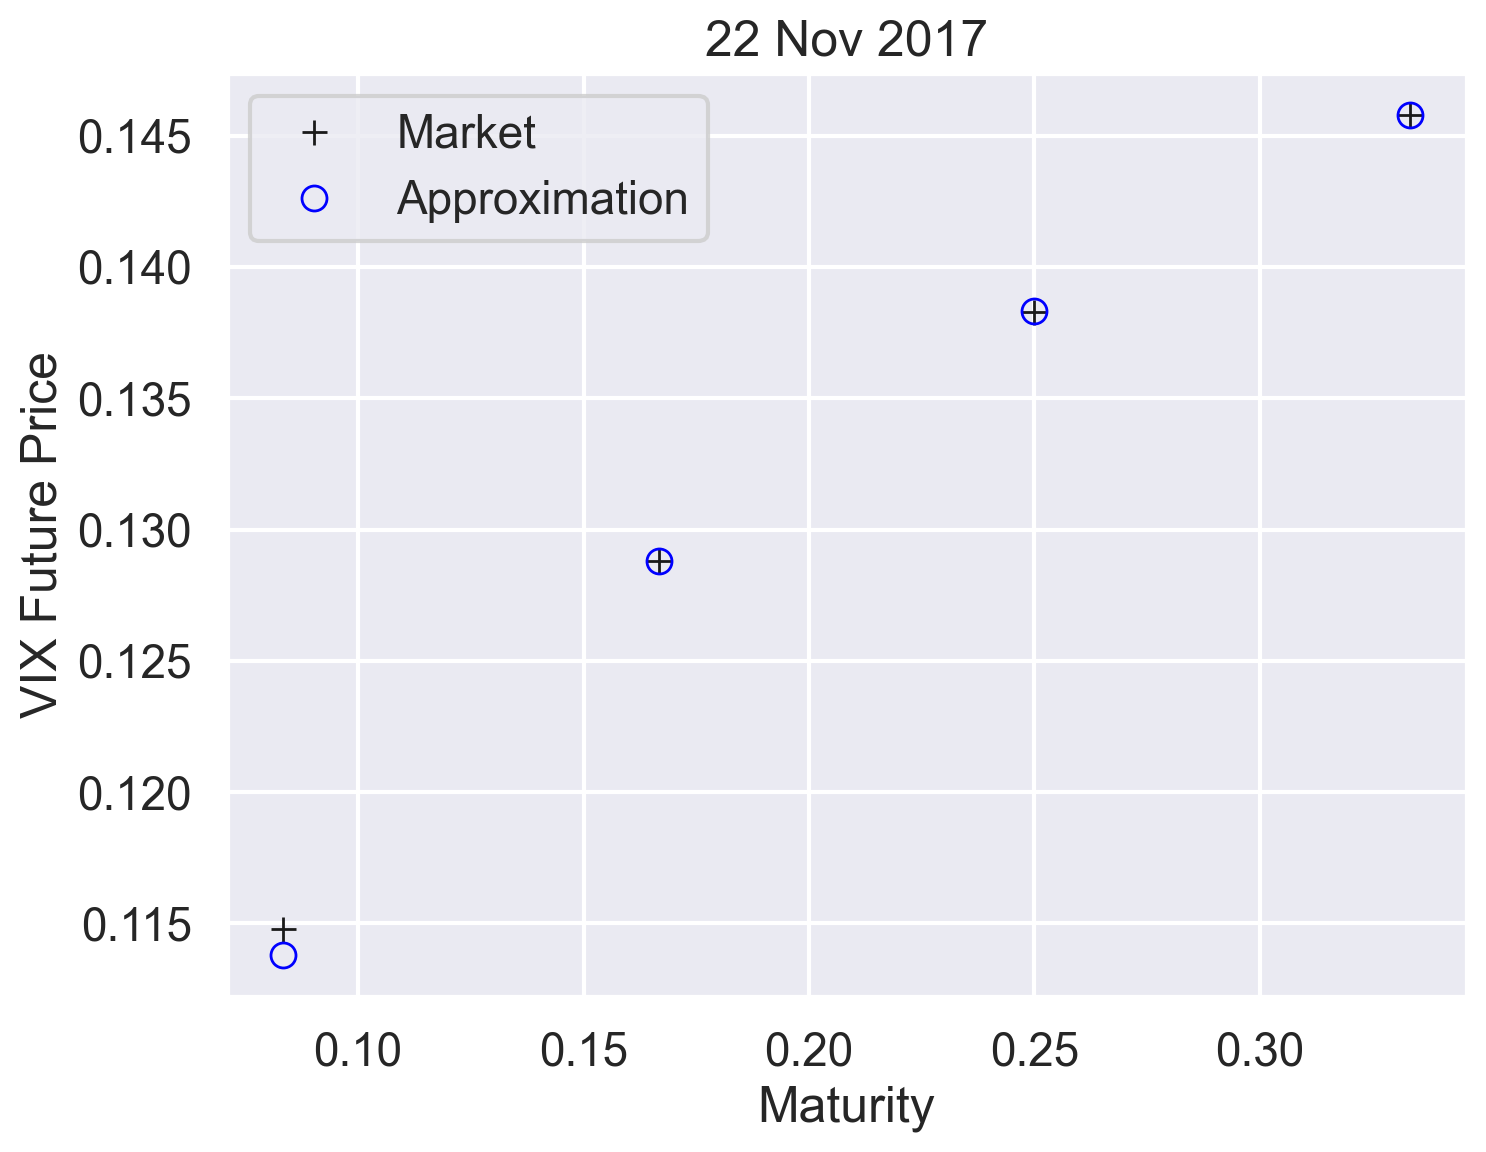

In [132]:
fig, ax = plt.subplots()
ax.plot(
    tab_mat[:4],
    tab_fut[:4],
    "+",
    color="k",
    label="Market",
)
ax.plot(
    tab_mat[:4],
    [fut_approx[T] for T in tab_mat[:4]],
    "o",
    color=COLORS[0],
    fillstyle="none",
    linewidth=1.0,
    label="Approximation",
)
ax.set_xlabel("Maturity")
ax.set_ylabel("VIX Future Price")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

## Calibration

In [ ]:
# TODO: redo calibration. assume xi0 piecewise constant.
# be careful with overlaps of maturities.

# 2023-02-15

In [128]:
# how to handle xi0 piecewise constant and the fact that maturities overlap?
# try the full smile with just one set of parameters.

In [3]:
import calibration
from utils import var_swap_robust, xi_curve_smooth

In [11]:
df_spx = pd.read_csv("data/spx_implied_vol_20230215.csv", index_col=0).dropna()
df_vix = pd.read_csv("data/vix_implied_vol_20230215.csv", index_col=0).dropna()
df_spx["Texp_days"] = (365.25 * df_spx["Texp"]).round().astype(int)
df_vix["Texp_days"] = (365.25 * df_vix["Texp"]).round().astype(int)
df_vix["Mid"] = (df_vix["Ask"] + df_vix["Bid"]) / 2

In [12]:
mats_days = df_vix["Texp_days"].unique()
print(mats_days)

[  7  14  20  28  35  63  91 126 154 182 217 245]


In [13]:
mats_days + 30

array([ 37,  44,  50,  58,  65,  93, 121, 156, 184, 212, 247, 275])

In [14]:
# # get xi0
# res_vs = var_swap_robust(ivol_data=df_spx)
# w_in = res_vs["vs_mid"] * res_vs["expiries"]
# xi0_smooth = xi_curve_smooth(res_vs["expiries"], w_in, eps=0.03)["xi_curve"]

In [15]:
# Extract unique maturities
vix_mats = df_vix["Texp"].unique()

In [65]:
# Filter the DataFrame for the first maturity
T = vix_mats[4]
df0 = df_vix[df_vix["Texp"] == T]

Ks = 1e-2 * df0["Strike"].to_numpy()
F = 1e-2 * df0["Fwd"].to_numpy()[0]
ks = np.log(Ks / F)
impvols = df0["Mid"].to_numpy()
weights = 1 / (df0["Ask"] - df0["Bid"]).to_numpy()

In [57]:
print(Ks)

[0.14  0.15  0.16  0.17  0.18  0.19  0.2   0.21  0.22  0.23  0.24  0.25
 0.26  0.27  0.28  0.29  0.3   0.31  0.32  0.325 0.33  0.34  0.35  0.36
 0.37  0.375 0.38  0.39  0.4   0.425 0.45  0.475 0.5   0.55  0.6   0.65
 0.7   0.75  0.8   0.85  0.9   0.95  1.    1.1   1.2   1.3   1.4   1.5
 1.6   1.7   1.8  ]


In [58]:
print(F)

0.21164480322904386


In [ ]:
# define optimization parameters

ORDER = 3
EPS = 1e-3
N_QUAD = 50

# xi0, H, eta_1, eta_2, lbd
x0_7d = np.array([0.04143876, 0.09227086, 6.18148555, 0.43356562, 0.12460595])
x0_35d = np.array([0.0454901, 0.13472347, 5.27801765, 0.58595415, 0.23542095])
x0_63d = np.array([0.0541161, 0.10168213, 4.79678822, 0.65320876, 0.32825003])

In [67]:
optim = calibration.optimize_calibration(
    x0=x0_35d,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    # weights=weights,
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.8658e-02                                    8.02e+00    
       1              3         1.8536e-02      1.22e-04       8.93e-03       7.75e+00    
       2              4         1.8112e-02      4.24e-04       1.15e-03       3.11e+01    
       3              5         1.6693e-02      1.42e-03       4.59e-03       3.87e-01    
       4              6         1.6645e-02      4.84e-05       3.82e-03       5.74e-01    
       5             14         1.6645e-02      0.00e+00       0.00e+00       5.74e-01    
`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 1.8658e-02, final cost 1.6645e-02, first-order optimality 5.74e-01.


In [68]:
print("Optimized parameters:")
optim.x

Optimized parameters:


array([0.0454901 , 0.13472347, 5.27801765, 0.58595415, 0.23542095])

In [69]:
x_optim = optim.x

F_approx, impvols_approx = calibration.fun(
    x_optim,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    return_error=False,
)

In [70]:
x_optim

array([0.0454901 , 0.13472347, 5.27801765, 0.58595415, 0.23542095])

In [71]:
0.308644 / np.sqrt(2 * 0.1)

np.float64(0.690148964847445)

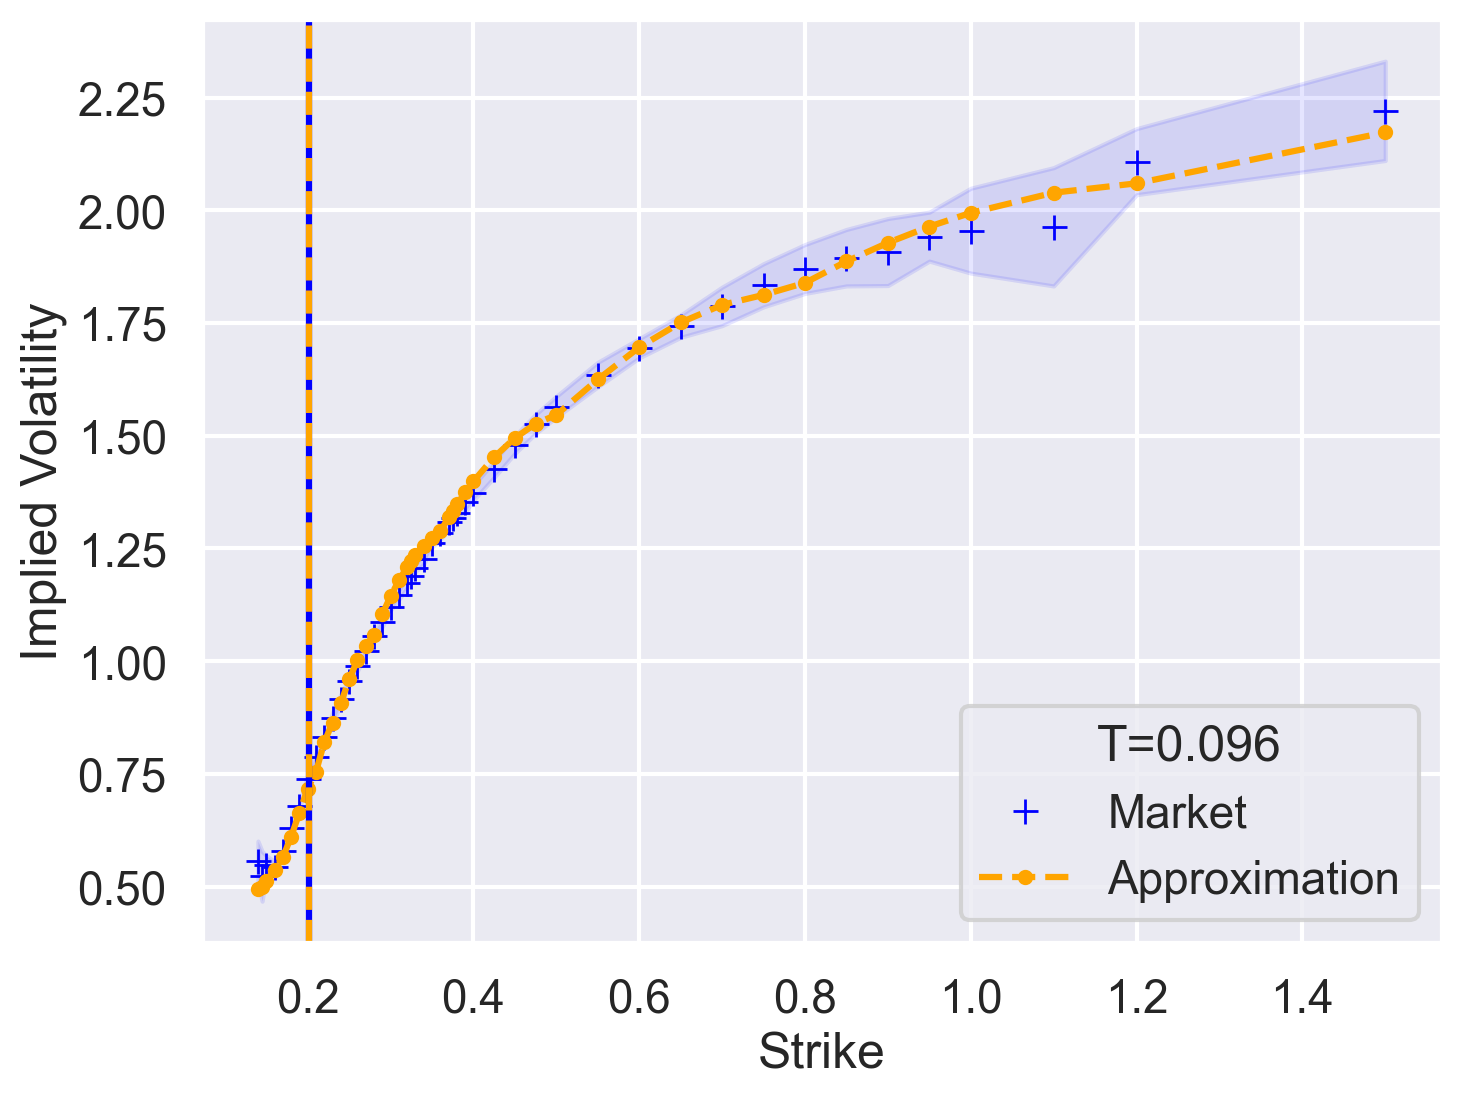

In [72]:
fig, ax = plt.subplots()
ax.plot(Ks, impvols, "+", color="blue", label="Market")
ax.fill_between(Ks, df0["Bid"], df0["Ask"], color="blue", alpha=0.1)
ax.plot(
    Ks,
    impvols_approx,
    ".--",
    color="orange",
    label="Approximation",
)
ax.axvline(F, color="blue", linestyle="-")
ax.axvline(F_approx, color="orange", linestyle="--")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.legend(title=f"T={T:.3f}")
plt.show()

In [73]:
# TODO: try to calibrate all smiles at once